# 2.1 — CAV Similarity Analysis  ·  *auto-generated vs. manually-curated concepts*

**Question.** Does a concept direction learned from an *automatically generated*
concept dataset point the **same way** as the direction learned from a
*manually curated reference* dataset? For each concept we train two CAVs — one
on the auto pool, one on the reference pool — and measure their **cosine
similarity**, layer by layer and backbone by backbone. A value near `1` means
the automatic dataset recovers essentially the same direction as the
human-curated one; values inside the noise band are indistinguishable from
chance.

### Design (what the code actually does)

* **CAV estimator — difference-of-means in *standardized* space.**
  At each layer activations are GAP-pooled to a vector, a `StandardScaler` is
  fit **once on the shared negative pool**, and *both* the auto and the
  reference activations are z-scored with that same scaler before computing
  `CAV = (μ_pos − μ_neg) / ‖·‖`. Fitting one scaler per layer on the negatives
  — and reusing it for both CAVs — is what guarantees the two vectors live in
  the **same standardized space**, so their cosine is meaningful. The z-score
  also keeps a few high-variance channels from dominating the direction.

* **Multi-pool averaging.** Each layer is summarised by *both* average- and
  max-pooling (`cfg.poolings = ['avg', 'max']`). A separate CAV is trained in
  each pooling's own standardized space and the reported similarity is the
  **mean cosine across poolings** — mirroring the multi-system averaging of
  Campi et al. and giving a more stable estimate than any single pooling.

* **Shared negatives, toggleable pool.** Both CAVs of a concept are trained
  against the **same** negative pool. `cfg.negative_kind` selects it:
  `'full'` → the uncropped VTCAV `/random` images (default);
  `'cropped'` → the union of the `random`-split crops across all concepts
  (in-layout negative patches).

* **Concept set (9, all treated identically).** `striped, dotted, chequered,
  wood, water, braided, bubbly, fibrous, veined` — every concept is read from
  the `single | multi | random` splits. (`fibrous` and `veined` were previously
  handled as an "orthogonal" control on a dedicated `orthogonal` split; they now
  go through exactly the same splits and aggregation as every other concept.)

* **Three backbones.** ResNet50, VGG16, InceptionV3 (torchvision, ImageNet
  pre-trained), each with 4 named layers at comparable relative depths
  (`L1…L4`, see registry). Flip `cfg.model_name`, or run the cross-backbone
  sweep at the bottom.

* **Dataset layout (matches exp-1-1).** Grid sources `augmented` and `vanilla`
  live at `crops/{auto_source}/{auto_source}_{crop_method}/{concept}/{split}/`
  with `crop_method ∈ {bbox, center_mask, largest_bbox, sliding_window}`.
  Prompt-variation buckets exist but are left out of the active sweep
  (`AUTO_SOURCES = ['augmented', 'vanilla']`).

* **Pre-processing.** Shared ImageNet mean/std; only `img_size` changes
  (224 for ResNet50/VGG16, 299 for InceptionV3).

### Outputs
Per-concept / per-layer cosine bar charts with a √-channel noise band, a
single-config run, a single-backbone sweep over `(auto_source × crop_method ×
split)`, a cross-backbone heat-map on relative layers, and one-sample t-tests
of the pooled cosines against a `0.2` reference.

## Setup & Imports

In [1]:
# Install dependencies
!pip install --quiet matplotlib seaborn scikit-learn pandas tqdm

In [2]:
import os
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

import pandas as pd

warnings.filterwarnings('ignore')

# Reproducibility
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.9.0+cu126


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def _resnet50_loader():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    return m.eval()


def _vgg16_loader():
    m = tv_models.vgg16(weights=tv_models.VGG16_Weights.IMAGENET1K_V1)
    return m.eval()


def _inception_v3_loader():
    m = tv_models.inception_v3(
        weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1,
        aux_logits=True,
    )
    m.aux_logits = False
    m.AuxLogits  = None
    return m.eval()


MODEL_REGISTRY: Dict[str, Dict] = {
    'resnet50': {
        'loader':        _resnet50_loader,
        'img_size':      224,
        'target_layers': ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2'],
        'layer_dims':    {'layer1.2': 256,  'layer2.3': 512,
                          'layer3.5': 1024, 'layer4.2': 2048},
    },
    'vgg16': {
        'loader':        _vgg16_loader,
        'img_size':      224,
        # End of conv blocks 2-5 (post-ReLU, pre-pool); channels 128/256/512/512
        'target_layers': ['features.8', 'features.15', 'features.22', 'features.29'],
        'layer_dims':    {'features.8': 128, 'features.15': 256,
                          'features.22': 512, 'features.29': 512},
    },
    'inception_v3': {
        'loader':        _inception_v3_loader,
        'img_size':      299,
        # Comparable depths across the three Inception stages
        'target_layers': ['Mixed_5d', 'Mixed_6c', 'Mixed_6e', 'Mixed_7c'],
        'layer_dims':    {'Mixed_5d': 288,  'Mixed_6c': 768,
                          'Mixed_6e': 768,  'Mixed_7c': 2048},
    },
}


def build_transform(img_size: int) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


print('Model registry ready ✓')
print(f'  Available backbones: {list(MODEL_REGISTRY.keys())}')

Model registry ready ✓
  Available backbones: ['resnet50', 'vgg16', 'inception_v3']


## Configuration

In [4]:
@dataclass
class Config:
    model_name: str = 'resnet50'

    auto_source:   str = 'vanilla'    # 'augmentation' | 'vanilla' | 'prompt_variations'
    crop_method:   str = 'sliding_window'  # 'bbox'|'center_mask'|'largest_bbox'|'sliding_window'
    split:         str = 'single'            # 'single'|'multi'|'random'
    negative_kind: str = 'full'            # 'full' | 'cropped'

    max_images:  int = 100
    batch_size:  int = 32
    num_workers: int = 2

    cav_classifier:           str = 'difference_of_means'   # 'difference_of_means' | 'logistic' | 'svm'
    cav_classifier_max_iter:  int = 5000

    poolings: List[str] = field(default_factory=lambda: ['avg', 'max'])

    output_dir:  str = '/kaggle/working/exp21_output'


cfg = Config()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

# Derived: layers + image size pulled from the registry
preset            = MODEL_REGISTRY[cfg.model_name]
cfg_target_layers = preset['target_layers']
cfg_img_size      = preset['img_size']
cfg_layer_dims    = preset['layer_dims']

print('Configuration loaded ✓')
print(f'  Backbone       : {cfg.model_name}  (img_size={cfg_img_size})')
print(f'  Target layers  : {cfg_target_layers}')
print(f'  Auto source    : {cfg.auto_source} / {cfg.crop_method} / split={cfg.split}')
print(f'  CAV classifier : {cfg.cav_classifier}')
print(f'  Poolings       : {cfg.poolings}  (mean cosine across them)')
print(f'  Negative kind  : {cfg.negative_kind}')


Configuration loaded ✓
  Backbone       : resnet50  (img_size=224)
  Target layers  : ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2']
  Auto source    : vanilla / sliding_window / split=single
  CAV classifier : difference_of_means
  Poolings       : ['avg', 'max']  (mean cosine across them)
  Negative kind  : full


In [5]:
ACG_NEW   = '/kaggle/input/datasets/alessandrocogollo/acg4cav-base-extraction/dataset'

DTD_ROOT  = '/kaggle/input/datasets/alessandrocogollo/vtcav-dataset/DTD-Concept'
DTD2_ROOT = '/kaggle/input/datasets/jmexpert/describable-textures-dataset-dtd/dtd/images'
T2I_ROOT  = '/kaggle/input/datasets/alessandrocogollo/zeroshot-t2i-concepts/concepts'

MANUAL_BASELINE: Dict[str, str] = {
    'striped':   f'{DTD2_ROOT}/striped',
    'dotted':    f'{DTD2_ROOT}/dotted',
    'chequered': f'{DTD2_ROOT}/chequered',
    'wood':      f'{T2I_ROOT}/wood/wood',
    'water':     f'{T2I_ROOT}/water/water',
    'braided':   f'{DTD2_ROOT}/braided',
    'bubbly':    f'{T2I_ROOT}/bubbly/bubbly',
    'fibrous':   f'{DTD2_ROOT}/fibrous',
    'veined':    f'{DTD2_ROOT}/veined',
}

CONCEPTS_MAIN  = ['striped', 'dotted', 'chequered', 'wood', 'water',
                  'braided', 'bubbly', 'fibrous', 'veined']

CROP_METHODS = ['bbox', 'center_mask', 'largest_bbox', 'sliding_window']
SPLITS       = ['single', 'multi', 'random']

GRID_AUTO_SOURCES  = ['augmented', 'vanilla']

PROMPT_VAR_SOURCES = ['augmentation_prompt_variations',
                      'vanilla_prompt_variations']

# AUTO_SOURCES = GRID_AUTO_SOURCES + PROMPT_VAR_SOURCES
AUTO_SOURCES = GRID_AUTO_SOURCES


def source_has_crop_method(auto_source: str) -> bool:
    """Prompt-variation buckets are not split by crop_method."""
    return auto_source not in PROMPT_VAR_SOURCES


def auto_dir(concept: str, auto_source: str, crop_method: str, split: str) -> str:
    """Build the path to an automatic (generated) concept directory.

    Two layouts are supported:
      * grid sources (augmented / vanilla):
          {auto_source}/{auto_source}_{crop_method}/{concept}/{split}
      * prompt-variation sources (no crop_method level):
          prompt_variations/{auto_source}/{concept}/{split}
    """
    if auto_source in PROMPT_VAR_SOURCES:
        return f'{ACG_NEW}/prompt_variations/{auto_source}/{concept}/{split}'
    bucket = f'{auto_source}/{auto_source}_{crop_method}'
    return f'{ACG_NEW}/{bucket}/{concept}/{split}'


def build_mapping(concepts: List[str], auto_source: str, crop_method: str,
                  split: str) -> Dict[str, List[str]]:
    """concept -> [auto_dir, manual_dir]"""
    return {
        c: [auto_dir(c, auto_source, crop_method, split), MANUAL_BASELINE[c]]
        for c in concepts
    }

NEGATIVE_FULL_DIR = '/kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random'


def cropped_negative_dirs(crop_method: str,
                          auto_source: str = 'vanilla') -> List[str]:
    """Union of the *random*-split crops for every concept under the chosen
    crop method — i.e., a pool of cropped patches from images that don't
    contain any of the target concepts."""
    return [auto_dir(c, auto_source, crop_method, 'random')
            for c in CONCEPTS_MAIN]


def resolve_negative_dirs(negative_kind: str, crop_method: str) -> List[str]:
    """'full'    -> uncropped VTCAV /random images (matches exp-2-1 of the thesis)
       'cropped' -> cropped negative patches (matches the new dataset layout)"""
    if negative_kind == 'full':
        return [NEGATIVE_FULL_DIR]
    if negative_kind == 'cropped':
        return cropped_negative_dirs(crop_method, auto_source='vanilla')
    raise ValueError(f'Unknown negative_kind: {negative_kind!r}')


print('Dataset path builders ready ✓')
print(f'  Auto sources      : {AUTO_SOURCES}')
print(f'  Sample auto path  : {auto_dir("striped", "vanilla", "sliding_window", "single")}')
print(f'  Sample manual path: {MANUAL_BASELINE["striped"]}')

Dataset path builders ready ✓
  Auto sources      : ['augmented', 'vanilla']
  Sample auto path  : /kaggle/input/datasets/alessandrocogollo/acg4cav-base-extraction/dataset/vanilla/vanilla_sliding_window/striped/single
  Sample manual path: /kaggle/input/datasets/jmexpert/describable-textures-dataset-dtd/dtd/images/striped


## Dataset Preparation

In [6]:
class ImageDirDataset(Dataset):
    """Loads all images recursively from one or more directories."""
    _EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff')

    def __init__(self, root_dirs, transform=None, max_images: Optional[int] = None):
        if isinstance(root_dirs, (str, os.PathLike)):
            root_dirs = [root_dirs]
        self.transform = transform
        paths = []
        for root in root_dirs:
            if not os.path.isdir(root):
                continue
            for dp, _, fns in os.walk(root):
                for fn in fns:
                    if fn.lower().endswith(self._EXTS):
                        paths.append(os.path.join(dp, fn))
        paths.sort()
        self.paths = paths[:max_images] if max_images else paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img


def count_images(d) -> int:
    """Count image files in one or more directories (non-recursive globs but
    recursive walk via the dataset class)."""
    if isinstance(d, (list, tuple)):
        return sum(count_images(x) for x in d)
    if not os.path.isdir(d):
        return 0
    exts = ImageDirDataset._EXTS
    return sum(1 for dp, _, fns in os.walk(d)
                 for fn in fns if fn.lower().endswith(exts))


print('Dataset utilities defined ✓')


Dataset utilities defined ✓


## Model & Feature Extractor  ·  *backbone-agnostic*

In [7]:
class FeatureExtractor(nn.Module):
    """
    Wraps any torchvision backbone listed in MODEL_REGISTRY and exposes
    intermediate activations at named modules via forward hooks. Spatial
    features are reduced to (B, C) with EACH requested pooling, so a single
    forward pass yields all poolings at once.

    forward(x) -> {layer_name: {pooling_name: (B, C) tensor}}.
    """
    def __init__(self, model_name: str, layers: List[str],
                 poolings: Optional[List[str]] = None):
        super().__init__()
        self.model_name   = model_name
        self.backbone     = MODEL_REGISTRY[model_name]['loader']()
        self._layer_names = list(layers)
        self._poolings    = list(poolings) if poolings else ['avg']
        self._hooks: List = []
        self._features: Dict[str, Dict[str, torch.Tensor]] = {}
        self._register_hooks()

    @property
    def layers(self) -> List[str]:
        return self._layer_names

    @property
    def poolings(self) -> List[str]:
        return self._poolings

    def _register_hooks(self):
        modules = dict(self.backbone.named_modules())
        for name in self._layer_names:
            if name not in modules:
                candidates = [k for k in modules
                              if k.startswith(name.split('.')[0])][:10]
                raise ValueError(
                    f"Layer '{name}' not found in {self.model_name}. "
                    f"Examples available: {candidates}"
                )
            handle = modules[name].register_forward_hook(self._make_hook(name))
            self._hooks.append(handle)

    def _pool(self, output: torch.Tensor) -> Dict[str, torch.Tensor]:
        # (B, C, H, W) -> {pool: (B, C)};  an already-(B, C) tensor passes through.
        out: Dict[str, torch.Tensor] = {}
        for p in self._poolings:
            if output.dim() == 4:
                out[p] = output.mean(dim=[2, 3]) if p == 'avg' else output.amax(dim=[2, 3])
            else:
                out[p] = output
        return out

    def _make_hook(self, name: str):
        def hook(module, inputs, output):
            self._features[name] = {p: t.detach().cpu()
                                    for p, t in self._pool(output).items()}
        return hook

    def forward(self, x: torch.Tensor) -> Dict[str, Dict[str, torch.Tensor]]:
        self._features.clear()
        with torch.no_grad():
            _ = self.backbone(x)
        return {k: dict(v) for k, v in self._features.items()}

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()


def build_extractor_and_transform(model_name: str):
    preset = MODEL_REGISTRY[model_name]
    fx = FeatureExtractor(model_name, preset['target_layers'],
                          poolings=cfg.poolings).to(DEVICE)
    tf = build_transform(preset['img_size'])
    return fx, tf


try:
    extractor.remove_hooks()                                # type: ignore[name-defined]
except Exception:
    pass

extractor, _transform = build_extractor_and_transform(cfg.model_name)
print(f'Model ready ✓  hooks on: {extractor.layers}  ·  poolings: {extractor.poolings}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


Model ready ✓  hooks on: ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2']  ·  poolings: ['avg', 'max']


## Activation Extraction Utilities

In [8]:
def extract_activations(image_source, layers, transform=None, fx=None,
                        max_images: Optional[int] = None
                        ) -> Dict[str, Dict[str, np.ndarray]]:
    """
    Extract activations at each layer for every image in *image_source* (a
    path or list of paths). Returns a NESTED dict:
        {layer_name: {pooling_name: (N, C) array}}.
    The set of poolings is whatever the extractor was built with (cfg.poolings).
    """
    fx        = fx        or extractor
    transform = transform or _transform
    poolings  = fx.poolings
    ds = ImageDirDataset(image_source, transform=transform, max_images=max_images)
    if len(ds) == 0:
        raise ValueError(f'No images found in: {image_source}')
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers, pin_memory=True)

    buf: Dict[str, Dict[str, List[np.ndarray]]] = {
        l: {p: [] for p in poolings} for l in layers}
    fx.eval()
    for x in loader:
        x = x.to(DEVICE, non_blocking=True)
        feats = fx(x)
        for l in layers:
            for p in poolings:
                buf[l][p].append(feats[l][p].numpy())
    return {l: {p: np.concatenate(v, axis=0) for p, v in d.items()}
            for l, d in buf.items()}


def precompute_negatives(layers, negative_kind: str, crop_method: str,
                        max_images: int = None,
                        fx=None, transform=None
                        ) -> Dict[str, Dict[str, np.ndarray]]:
    """Pre-compute the negative-pool activations once for a given config."""
    max_images = max_images or cfg.max_images
    neg_dirs   = resolve_negative_dirs(negative_kind, crop_method)
    print(f'Pre-computing negative activations ({negative_kind}, '
          f'crop_method={crop_method}) ...')
    acts = extract_activations(neg_dirs, layers, transform=transform, fx=fx,
                               max_images=max_images)
    for l, pooldict in acts.items():
        shapes = ', '.join(f'{p}:{tuple(arr.shape)}' for p, arr in pooldict.items())
        print(f'  {l:<14}: {shapes}')
    return acts


# Pre-compute current-config random (negative) activations once
random_acts: Dict[str, Dict[str, np.ndarray]] = precompute_negatives(
    cfg_target_layers, cfg.negative_kind, cfg.crop_method)
print('Random activations ready')

Pre-computing negative activations (full, crop_method=sliding_window) ...
  layer1.2      : avg:(100, 256), max:(100, 256)
  layer2.3      : avg:(100, 512), max:(100, 512)
  layer3.5      : avg:(100, 1024), max:(100, 1024)
  layer4.2      : avg:(100, 2048), max:(100, 2048)
Random activations ready


## CAV Training Core

In [9]:
def train_cav(
    pos_acts: np.ndarray,
    neg_acts: np.ndarray,
    classifier: str = 'difference_of_means',
    scaler: Optional[StandardScaler] = None,
) -> Tuple[np.ndarray, None]:
    """
    Difference-of-means CAV in the STANDARDIZED space. The scaler should be
    fit on the negative pool (shared reference) and reused for pos/neg of
    BOTH CAVs (auto & ref) at a given layer — otherwise cos(cav_auto, cav_ref)
    would not live in the same space.
    """
    if scaler is None:
        scaler = StandardScaler().fit(neg_acts)
    pos_z = scaler.transform(pos_acts)
    neg_z = scaler.transform(neg_acts)

    if classifier == 'difference_of_means':
        diff = pos_z.mean(0) - neg_z.mean(0)
        cav  = diff / (np.linalg.norm(diff) + 1e-12)
        return cav.astype(np.float32), None

    # Backward-compat trained classifiers (on standardized X)
    X = np.concatenate([pos_z, neg_z], 0)
    y = np.array([1] * len(pos_z) + [0] * len(neg_z))
    if classifier == 'logistic':
        clf = LogisticRegression(max_iter=cfg.cav_classifier_max_iter,
                                 solver='liblinear', class_weight='balanced',
                                 C=1.0, random_state=GLOBAL_SEED)
    elif classifier == 'svm':
        clf = LinearSVC(max_iter=cfg.cav_classifier_max_iter, C=1.0,
                        random_state=GLOBAL_SEED)
    else:
        raise ValueError(f'Unknown classifier: {classifier}')
    clf.fit(X, y)
    w = clf.coef_[0]
    return (w / (np.linalg.norm(w) + 1e-12)).astype(np.float32), None


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(1.0 - cosine(a, b))


def run_experiment(
    mapping_name: str,
    mappings: Dict[str, List[str]],
    layers: Optional[List[str]] = None,
    neg_acts: Optional[Dict[str, np.ndarray]] = None,
    fx=None, transform=None,
    verbose: bool = True,
) -> Dict[str, Dict[str, float]]:
    """
    For each concept, extract activations from the reference and auto-generated
    pools, train two CAVs (both vs. the same random pool, with the same scaler
    fitted on the random pool for the current layer), and compute the cosine
    similarity between them for every layer.

    Returns {concept: {layer: cosine_similarity}}.
    """
    layers   = layers   or cfg_target_layers
    neg_acts = neg_acts if neg_acts is not None else random_acts

    if verbose:
        print(f'EXPERIMENT — {mapping_name}')

    results: Dict[str, Dict[str, float]] = {}
    poolings = getattr(fx or extractor, 'poolings', cfg.poolings)
    scalers = {l: {p: StandardScaler().fit(neg_acts[l][p]) for p in poolings}
               for l in layers}

    for concept, (a_dir, r_dir) in tqdm(mappings.items(),
                                        desc=mapping_name, disable=not verbose):
        if not (os.path.isdir(a_dir) and os.path.isdir(r_dir)):
            if verbose:
                print(f'  ⚠  Skipping {concept}: missing dir(s).')
            continue
        if count_images(a_dir) == 0 or count_images(r_dir) == 0:
            if verbose:
                print(f'  ⚠  Skipping {concept}: empty dir(s).')
            continue
        ref_acts  = extract_activations(r_dir, layers,
                                        transform=transform, fx=fx,
                                        max_images=cfg.max_images)
        auto_acts = extract_activations(a_dir, layers,
                                        transform=transform, fx=fx,
                                        max_images=cfg.max_images)

        results[concept] = {}
        for layer in layers:
            # mean cosine across poolings: one CAV (+ its own scaler) per pooling
            per_pool = []
            for p in poolings:
                sc = scalers[layer][p]
                c_cav, _ = train_cav(ref_acts[layer][p],  neg_acts[layer][p],
                                     cfg.cav_classifier, scaler=sc)
                a_cav, _ = train_cav(auto_acts[layer][p], neg_acts[layer][p],
                                     cfg.cav_classifier, scaler=sc)
                per_pool.append(cosine_similarity(c_cav, a_cav))
            results[concept][layer] = float(np.mean(per_pool))

    if verbose:
        print(f'\n{mapping_name} — Cosine Similarity (auto CAV vs. reference CAV):')
        header = f'{"Concept":<14}' + ''.join(f'{l:>16}' for l in layers)
        print(header)
        print('-' * len(header))
        for concept, layer_sims in results.items():
            row = f'{concept:<14}' + ''.join(f'{layer_sims[l]:>16.4f}'
                                              for l in layers)
            print(row)
    return results


def plot_experiment(results, title, save_path, layer_dims=None, layers=None):
    layers     = layers     or cfg_target_layers
    layer_dims = layer_dims if layer_dims is not None else cfg_layer_dims
    concepts   = list(results.keys())
    if not concepts:
        print(f'(no concepts to plot for "{title}")')
        return
    n_layers = len(layers)
    x        = np.arange(len(concepts))
    width    = 0.8 / n_layers
    palette  = sns.color_palette('tab10', n_layers)

    fig, ax = plt.subplots(figsize=(max(10, len(concepts) * 1.8), 5))
    for j, (layer, color) in enumerate(zip(layers, palette)):
        sims   = [results[c][layer] for c in concepts]
        offset = (j - n_layers / 2 + 0.5) * width
        ax.bar(x + offset, sims, width, label=layer, color=color,
               alpha=0.85, edgecolor='white', linewidth=0.5)

    # noise band 95% — relative to the *shallowest* (= worst-case) layer
    if layer_dims and all(l in layer_dims for l in layers):
        noise = 2.0 / np.sqrt(layer_dims[layers[0]])
        ax.axhspan(-noise, noise, color='lightgray', alpha=0.4,
                   label=f'noise band 95% ({layers[0]}, ±{noise:.3f})', zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(concepts, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Cosine Similarity (auto CAV vs. reference CAV)')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axhline(0,   color='red',  linestyle=':',  lw=1.0)
    ax.axhline(0.9, color='gray', linestyle='--', lw=1.0, label='high alignment (0.9)')
    ax.set_ylim([-0.5, 1.1])
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {save_path}')


print(f'CAV utilities defined ✓  (method = {cfg.cav_classifier})')


CAV utilities defined ✓  (method = difference_of_means)


---
## Single-config Run  ·  *uses the current `cfg.model_name`*

In [10]:
MAPPINGS_MAIN  = build_mapping(CONCEPTS_MAIN,  cfg.auto_source,
                               cfg.crop_method, cfg.split)

tag = (f'{cfg.model_name}__{cfg.auto_source}__{cfg.crop_method}__'
       f'{cfg.split}__neg-{cfg.negative_kind}')
print(f'Run tag: {tag}')
print(f'  Concepts: {list(MAPPINGS_MAIN.keys())}')


Run tag: resnet50__vanilla__sliding_window__single__neg-full
  Concepts: ['striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly', 'fibrous', 'veined']


EXPERIMENT — All / resnet50__vanilla__sliding_window__single__neg-full


All / resnet50__vanilla__sliding_window__single__neg-full:   0%|          | 0/9 [00:00<?, ?it/s]


All / resnet50__vanilla__sliding_window__single__neg-full — Cosine Similarity (auto CAV vs. reference CAV):
Concept               layer1.2        layer2.3        layer3.5        layer4.2
------------------------------------------------------------------------------
striped                 0.7964          0.8071          0.8427          0.8743
dotted                  0.2109          0.2031          0.4126          0.2327
chequered               0.4945          0.6164          0.7086          0.6580
wood                    0.3403          0.4751          0.6352          0.5351
water                   0.3968          0.5799          0.5932          0.2917
braided                 0.4788          0.5226          0.7154          0.6884
bubbly                  0.2383          0.2969          0.4700          0.5476
fibrous                 0.6638          0.6439          0.7116          0.6767
veined                  0.2629          0.5062          0.6368          0.6162


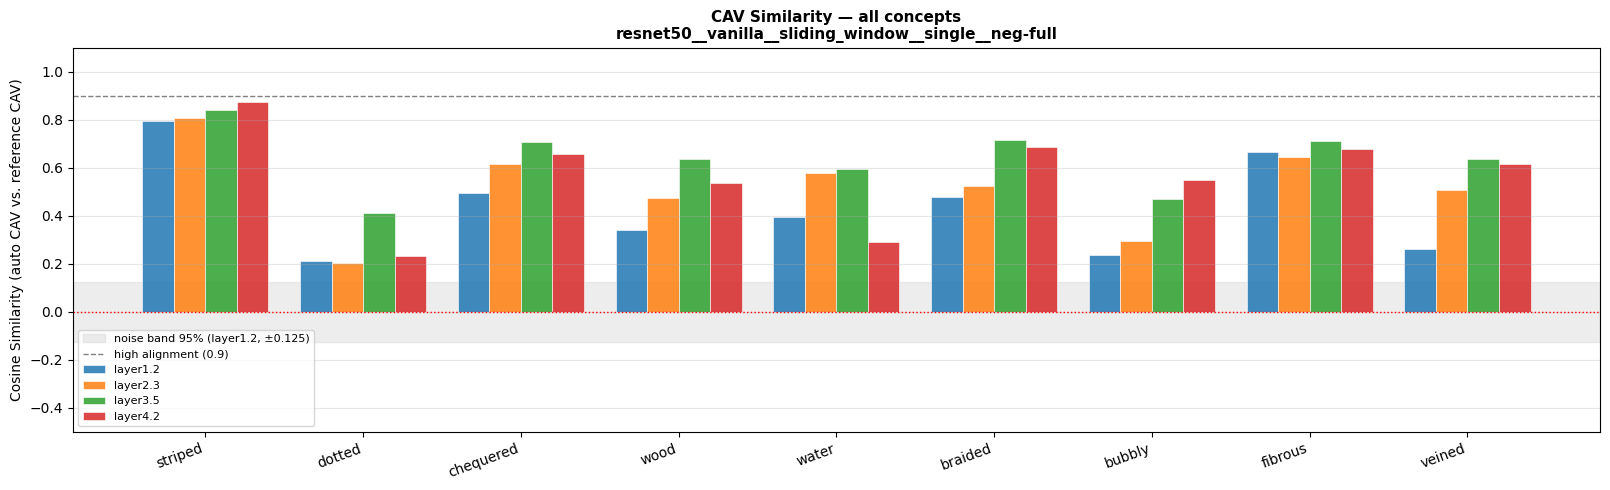

Figure saved to /kaggle/working/exp21_output/resnet50__vanilla__sliding_window__single__neg-full_all.png


In [11]:
all_results = run_experiment(f'All / {tag}', MAPPINGS_MAIN)
plot_experiment(
    all_results,
    title=f'CAV Similarity — all concepts\n{tag}',
    save_path=f'{cfg.output_dir}/{tag}_all.png',
)


---
## Full Sweep — all (auto_source × crop_method × split) on the current backbone

This is the *single-backbone* sweep. The cross-backbone sweep that runs all
three networks is the cell after the heat-map.

In [12]:
print('Auto-source × crop_method × split availability '
      '(# concepts with images, out of all):')
for a_src in AUTO_SOURCES:
    methods = CROP_METHODS if source_has_crop_method(a_src) else ['none']
    for m in methods:
        for s in SPLITS:
            present = [c for c in CONCEPTS_MAIN
                       if count_images(auto_dir(c, a_src, m, s)) > 0]
            ok = '✓' if present else '✗'
            print(f'  {ok} {a_src[:18]:>18}/{m:<13}/{s:<10}  '
                  f'({len(present)}/{len(CONCEPTS_MAIN)} concepts)')


Auto-source × crop_method × split availability (# concepts with images, out of all):
  ✓          augmented/bbox         /single      (9/9 concepts)
  ✓          augmented/bbox         /multi       (9/9 concepts)
  ✓          augmented/bbox         /random      (9/9 concepts)
  ✓          augmented/center_mask  /single      (9/9 concepts)
  ✓          augmented/center_mask  /multi       (9/9 concepts)
  ✓          augmented/center_mask  /random      (9/9 concepts)
  ✓          augmented/largest_bbox /single      (9/9 concepts)
  ✓          augmented/largest_bbox /multi       (9/9 concepts)
  ✓          augmented/largest_bbox /random      (9/9 concepts)
  ✓          augmented/sliding_window/single      (9/9 concepts)
  ✓          augmented/sliding_window/multi       (9/9 concepts)
  ✓          augmented/sliding_window/random      (9/9 concepts)
  ✓            vanilla/bbox         /single      (9/9 concepts)
  ✓            vanilla/bbox         /multi       (9/9 concepts)
  ✓            v

In [13]:
def sweep_backbone(
    model_name: str,
    neg_acts: Optional[Dict[str, np.ndarray]] = None,
    concepts: Optional[List[str]] = None,
    verbose: bool = False,
) -> Dict[str, Dict[str, Dict[str, float]]]:
    """
    Run the full (auto_source x crop_method x split) sweep on a SINGLE
    backbone over ALL concepts (CONCEPTS_MAIN). Every concept — fibrous and
    veined included — is read from the single | multi | random splits.

    Returns {grid_tag: {concept: {layer: cosine_sim}}}.
    """
    global extractor, _transform   # we mutate the module-level handles

    if concepts is None:
        concepts = CONCEPTS_MAIN

    # Switch backbone if needed
    if extractor.model_name != model_name:
        extractor.remove_hooks()
        extractor, _transform = build_extractor_and_transform(model_name)

    preset   = MODEL_REGISTRY[model_name]
    layers_b = preset['target_layers']

    _cached_neg: Optional[Dict[str, np.ndarray]] = None
    if neg_acts is not None:
        _cached_neg = neg_acts  # caller-supplied pool, reuse for every cell
    elif cfg.negative_kind == 'full':
        _cached_neg = precompute_negatives(
            layers_b, cfg.negative_kind, CROP_METHODS[0],
            fx=extractor, transform=_transform)

    sweep: Dict[str, Dict[str, Dict[str, float]]] = {}
    for a_src in AUTO_SOURCES:
        has_cm  = source_has_crop_method(a_src)
        # Prompt-variation buckets have no crop_method sub-level → single pass.
        methods = CROP_METHODS if has_cm else ['none']
        for m in methods:

            if _cached_neg is not None:
                neg_b = _cached_neg
            else:
                m_for_neg = m if has_cm else CROP_METHODS[0]
                neg_b = precompute_negatives(
                    layers_b, cfg.negative_kind, m_for_neg,
                    fx=extractor, transform=_transform)

            for s in SPLITS:
                grid_tag = (f'{model_name}__{a_src}__{m}__{s}'
                            f'__neg-{cfg.negative_kind}')
                print(f'\n{"#" * 72}\n#  {grid_tag}\n{"#" * 72}')
                # keep only concepts that actually have images in this cell
                present = [c for c in concepts
                           if count_images(auto_dir(c, a_src, m, s)) > 0]
                if not present:
                    print(f'  ⚠  empty: '
                          f'{auto_dir(concepts[0], a_src, m, s)}')
                    continue
                mappings = {
                    c: [auto_dir(c, a_src, m, s), MANUAL_BASELINE[c]]
                    for c in present
                }
                try:
                    sweep[grid_tag] = run_experiment(
                        grid_tag, mappings,
                        layers=layers_b, neg_acts=neg_b,
                        fx=extractor, transform=_transform,
                        verbose=verbose,
                    )
                except Exception as e:
                    print(f'  ✗ Error: {e}')
                    continue
    return sweep


# Sweep on the CURRENT backbone (cfg.model_name)
grid_results: Dict[str, Dict[str, Dict[str, float]]] = sweep_backbone(
    cfg.model_name, neg_acts=random_acts, verbose=False)
print(f'\nSweep complete — {len(grid_results)} cells ran on {cfg.model_name}.')
print(f'  Concepts per cell: {len(CONCEPTS_MAIN)}')



########################################################################
#  resnet50__augmented__bbox__single__neg-full
########################################################################

########################################################################
#  resnet50__augmented__bbox__multi__neg-full
########################################################################

########################################################################
#  resnet50__augmented__bbox__random__neg-full
########################################################################

########################################################################
#  resnet50__augmented__center_mask__single__neg-full
########################################################################

########################################################################
#  resnet50__augmented__center_mask__multi__neg-full
########################################################################

#################

---
## Heat-map and Summary Tables  ·  *current backbone*

Saved grid summary → /kaggle/working/exp21_output/grid_summary_resnet50_neg-full.csv
  Rows: 864 | concepts: 9


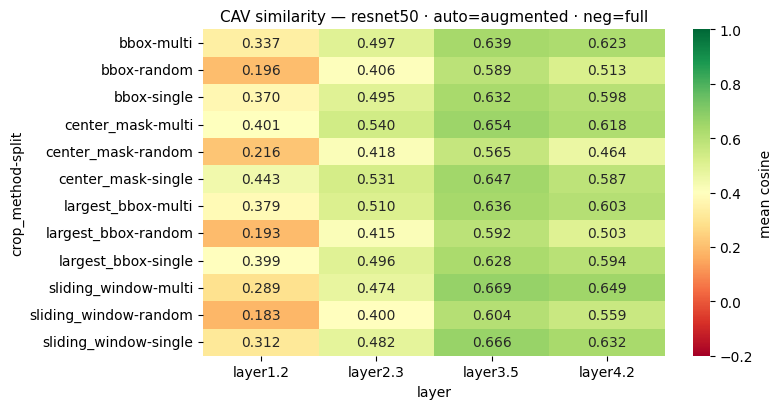

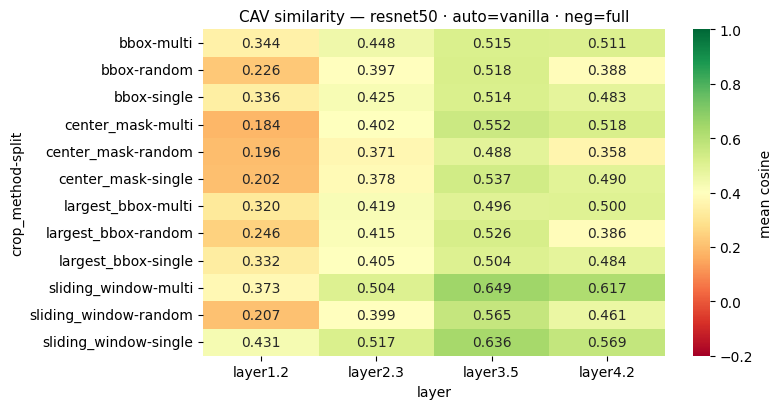

In [14]:
def grid_to_summary(grid: Dict[str, Dict[str, Dict[str, float]]],
                    layers: List[str]) -> pd.DataFrame:
    """
    Flatten sweep dict into a tidy per-concept-per-layer DataFrame.
    """
    rows = []
    for grid_tag, res in grid.items():
        parts = grid_tag.split('__')
        backbone, a_src, m, s = parts[0], parts[1], parts[2], parts[3]
        for layer in layers:
            for concept, layer_sims in res.items():
                if layer not in layer_sims:
                    continue
                rows.append({
                    'backbone':      backbone,
                    'auto_source':   a_src,
                    'crop_method':   m,
                    'split':         s,
                    'layer':         layer,
                    'concept':       concept,
                    'cos_sim':       layer_sims[layer],
                })
    return pd.DataFrame(rows)


def aggregate_summary(df: pd.DataFrame) -> pd.DataFrame:
    """One row per (backbone, auto_source, crop_method, split, layer)."""
    if df.empty:
        return df
    keys = ['backbone', 'auto_source', 'crop_method', 'split', 'layer']
    if 'layer_rel' in df.columns:
        keys.insert(5, 'layer_rel')
    return (
        df.groupby(keys, as_index=False)
        .agg(mean_cos=('cos_sim', 'mean'),
             std_cos=('cos_sim', 'std'),
             n_concepts=('concept', 'count'))
    )


def plot_grid_heatmap(summary_df: pd.DataFrame, backbone: str,
                      layers: List[str], output_dir: str):
    """Heat-map per auto_source; rows = (crop_method, split), cols = layer."""
    agg = aggregate_summary(summary_df[summary_df.backbone == backbone])
    if agg.empty:
        return
    for a_src in agg['auto_source'].unique():
        sub = agg[agg.auto_source == a_src]
        if sub.empty:
            continue
        pivot = sub.pivot_table(
            index=['crop_method', 'split'], columns='layer',
            values='mean_cos').reindex(columns=layers)
        plt.figure(figsize=(8, max(4, 0.35 * len(pivot))))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=-0.2, vmax=1.0, cbar_kws={'label': 'mean cosine'})
        plt.title(
            f'CAV similarity — {backbone} · auto={a_src} · '
            f'neg={cfg.negative_kind}', fontsize=11)
        plt.tight_layout()
        out = (f'{output_dir}/heatmap_{backbone}_{a_src}'
               f'_neg-{cfg.negative_kind}.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()


if grid_results:
    summary_df = grid_to_summary(grid_results, cfg_target_layers)
    csv_path   = (f'{cfg.output_dir}/grid_summary_{cfg.model_name}'
                  f'_neg-{cfg.negative_kind}.csv')
    summary_df.to_csv(csv_path, index=False)
    print(f'Saved grid summary → {csv_path}')
    print(f'  Rows: {len(summary_df)} | concepts: {summary_df["concept"].nunique()}')
    plot_grid_heatmap(summary_df, cfg.model_name, cfg_target_layers, cfg.output_dir)
else:
    summary_df = pd.DataFrame()
    print('No grid results to summarise.')


---
## **Multi-backbone sweep — runs all 3 networks back-to-back**

In [15]:
multi_grid_results: Dict[str, Dict[str, Dict[str, Dict[str, float]]]] = {}
multi_layer_dims:   Dict[str, Dict[str, int]] = {}

for backbone in MODEL_REGISTRY:
    print('\n' + '-'* 72)
    print(f'  BACKBONE: {backbone}')
    print('-' * 72)
    multi_layer_dims[backbone] = MODEL_REGISTRY[backbone]['layer_dims']
    multi_grid_results[backbone] = sweep_backbone(
        backbone, neg_acts=None, concepts=None, verbose=False)

print('\n✓ Multi-backbone sweep complete.')
for b, g in multi_grid_results.items():
    print(f'  {b:<14} → {len(g)} grid cells')



------------------------------------------------------------------------
  BACKBONE: resnet50
------------------------------------------------------------------------
Pre-computing negative activations (full, crop_method=bbox) ...
  layer1.2      : avg:(100, 256), max:(100, 256)
  layer2.3      : avg:(100, 512), max:(100, 512)
  layer3.5      : avg:(100, 1024), max:(100, 1024)
  layer4.2      : avg:(100, 2048), max:(100, 2048)

########################################################################
#  resnet50__augmented__bbox__single__neg-full
########################################################################

########################################################################
#  resnet50__augmented__bbox__multi__neg-full
########################################################################

########################################################################
#  resnet50__augmented__bbox__random__neg-full
############################################################

100%|██████████| 528M/528M [00:02<00:00, 243MB/s]


Pre-computing negative activations (full, crop_method=bbox) ...
  features.8    : avg:(100, 128), max:(100, 128)
  features.15   : avg:(100, 256), max:(100, 256)
  features.22   : avg:(100, 512), max:(100, 512)
  features.29   : avg:(100, 512), max:(100, 512)

########################################################################
#  vgg16__augmented__bbox__single__neg-full
########################################################################

########################################################################
#  vgg16__augmented__bbox__multi__neg-full
########################################################################

########################################################################
#  vgg16__augmented__bbox__random__neg-full
########################################################################

########################################################################
#  vgg16__augmented__center_mask__single__neg-full
###########################################

100%|██████████| 104M/104M [00:00<00:00, 235MB/s] 


Pre-computing negative activations (full, crop_method=bbox) ...
  Mixed_5d      : avg:(100, 288), max:(100, 288)
  Mixed_6c      : avg:(100, 768), max:(100, 768)
  Mixed_6e      : avg:(100, 768), max:(100, 768)
  Mixed_7c      : avg:(100, 2048), max:(100, 2048)

########################################################################
#  inception_v3__augmented__bbox__single__neg-full
########################################################################

########################################################################
#  inception_v3__augmented__bbox__multi__neg-full
########################################################################

########################################################################
#  inception_v3__augmented__bbox__random__neg-full
########################################################################

########################################################################
#  inception_v3__augmented__center_mask__single__neg-full
#############

In [16]:
all_rows = []
for backbone, grid in multi_grid_results.items():
    layers_b  = MODEL_REGISTRY[backbone]['target_layers']
    layer_rel = {l: f'L{i+1}' for i, l in enumerate(layers_b)}
    df_b      = grid_to_summary(grid, layers_b)
    if df_b.empty:
        continue
    df_b['layer_rel'] = df_b['layer'].map(layer_rel)
    all_rows.append(df_b)

if all_rows:
    summary_all = pd.concat(all_rows, ignore_index=True)
    csv_path = (f'{cfg.output_dir}/multi_backbone_grid_summary'
                f'_neg-{cfg.negative_kind}.csv')
    summary_all.to_csv(csv_path, index=False)
    print(f'Saved multi-backbone summary → {csv_path}')
    print(f'  Total rows      : {len(summary_all)}')
    print(f'  Concepts covered: {sorted(summary_all["concept"].unique())}')
    with pd.option_context('display.max_columns', None, 'display.width', 200):
        print(summary_all.head(20).to_string(index=False))
else:
    summary_all = pd.DataFrame()
    print('No multi-backbone results yet.')


Saved multi-backbone summary → /kaggle/working/exp21_output/multi_backbone_grid_summary_neg-full.csv
  Total rows      : 2592
  Concepts covered: ['braided', 'bubbly', 'chequered', 'dotted', 'fibrous', 'striped', 'veined', 'water', 'wood']
backbone auto_source crop_method  split    layer   concept  cos_sim layer_rel
resnet50   augmented        bbox single layer1.2   striped 0.563972        L1
resnet50   augmented        bbox single layer1.2    dotted 0.235838        L1
resnet50   augmented        bbox single layer1.2 chequered 0.642286        L1
resnet50   augmented        bbox single layer1.2      wood 0.149384        L1
resnet50   augmented        bbox single layer1.2     water 0.420139        L1
resnet50   augmented        bbox single layer1.2   braided 0.391463        L1
resnet50   augmented        bbox single layer1.2    bubbly 0.260492        L1
resnet50   augmented        bbox single layer1.2   fibrous 0.412622        L1
resnet50   augmented        bbox single layer1.2    veined

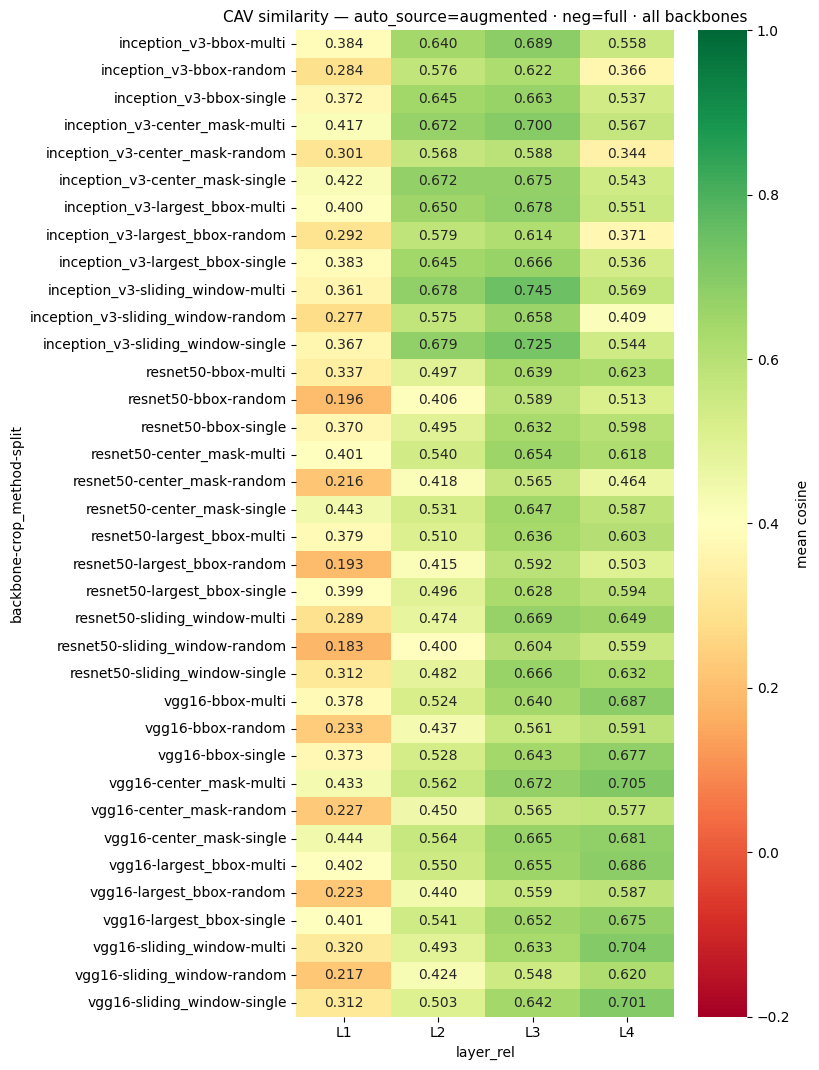

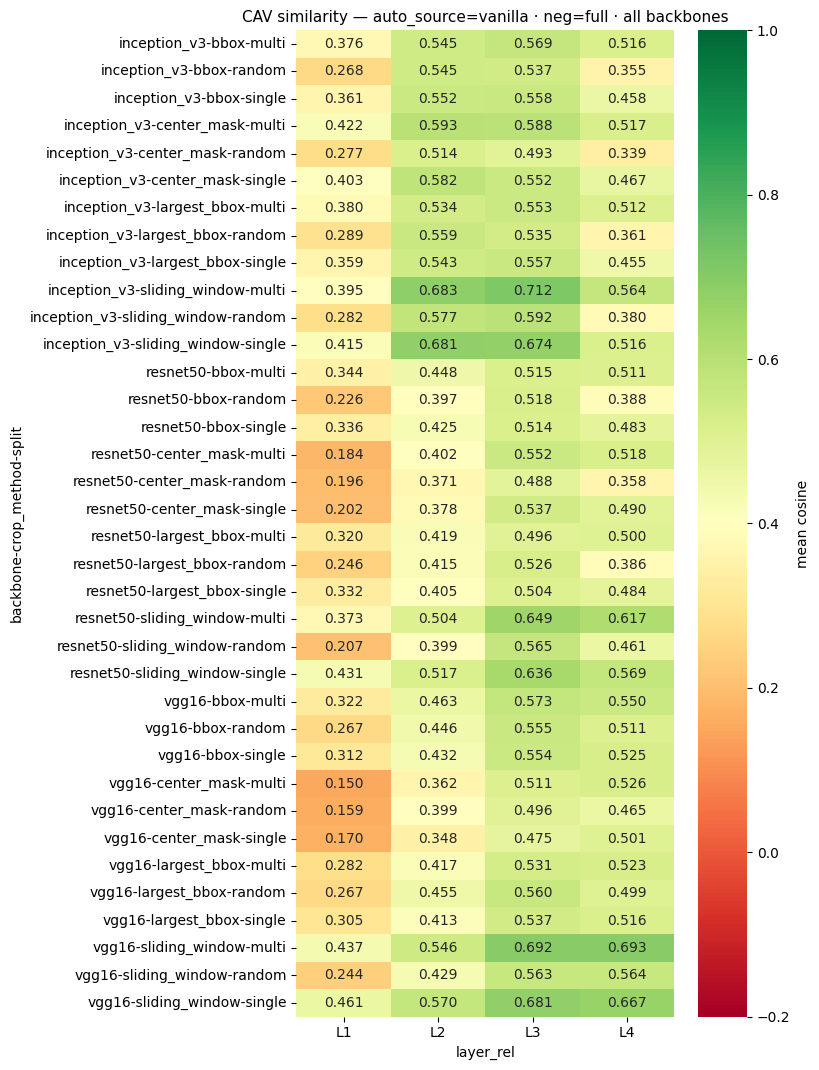

In [17]:
if not summary_all.empty:
    agg_all = aggregate_summary(summary_all)
    for a_src in agg_all['auto_source'].unique():
        sub = agg_all[agg_all.auto_source == a_src]
        if sub.empty:
            continue
        pivot = sub.pivot_table(
            index=['backbone', 'crop_method', 'split'],
            columns='layer_rel',
            values='mean_cos',
        ).reindex(columns=['L1', 'L2', 'L3', 'L4'])
        plt.figure(figsize=(8, max(6, 0.30 * len(pivot))))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=-0.2, vmax=1.0, cbar_kws={'label': 'mean cosine'})
        plt.title(
            f'CAV similarity — auto_source={a_src} · '
            f'neg={cfg.negative_kind} · all backbones', fontsize=11)
        plt.tight_layout()
        out = (f'{cfg.output_dir}/multi_heatmap_{a_src}'
               f'_neg-{cfg.negative_kind}.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()


---
## Cross-backbone statistical comparison

In [18]:
from scipy.stats import ttest_1samp

if not summary_all.empty:
    print('Mean cosine per (backbone x layer_rel), pooled across configs:')
    pooled = (
        summary_all
        .groupby(['backbone', 'layer_rel'])['cos_sim']
        .agg(['mean', 'std', 'count'])
        .round(4)
    )
    print(pooled.to_string())

    print('\n\nOne-sample t-test: is mean cosine > 0.2 '
          'per (backbone, layer_rel)?')
    print('(Threshold >= 5 observations required for reliable p-values)')
    for backbone in summary_all['backbone'].unique():
        for lr in ['L1', 'L2', 'L3', 'L4']:
            vals = summary_all[
                (summary_all.backbone == backbone) &
                (summary_all.layer_rel == lr)
            ]['cos_sim'].values
            if len(vals) < 5:
                continue
            t, p = ttest_1samp(vals, popmean=0.2)
            sig = ('***' if p < 0.001 else '**' if p < 0.01
                   else '*' if p < 0.05 else 'ns')
            print(f'  {backbone:<14} {lr}  '
                  f'n={len(vals):>3}  mu={vals.mean():.4f}  '
                  f't={t:+.3f}  p={p:.2e}  {sig}')


Mean cosine per (backbone x layer_rel), pooled across configs:
                          mean     std  count
backbone     layer_rel                       
inception_v3 L1         0.3536  0.1814    216
             L2         0.6037  0.1234    216
             L3         0.6226  0.1399    216
             L4         0.4724  0.2025    216
resnet50     L1         0.2964  0.1676    216
             L2         0.4476  0.1439    216
             L3         0.5843  0.1135    216
             L4         0.5294  0.1699    216
vgg16        L1         0.3057  0.2092    216
             L2         0.4707  0.1636    216
             L3         0.5901  0.1325    216
             L4         0.6013  0.1458    216


One-sample t-test: is mean cosine > 0.2 per (backbone, layer_rel)?
(Threshold >= 5 observations required for reliable p-values)
  resnet50       L1  n=216  mu=0.2964  t=+8.458  p=4.17e-15  ***
  resnet50       L2  n=216  mu=0.4476  t=+25.282  p=2.46e-66  ***
  resnet50       L3  n=216  mu=0